# Les stratégies Quiver, répliquées — §14 → §14.2

> **Volet extrait du notebook 11** (les répliques Quiver) — cellules et **sorties figées** copiées
> telles quelles depuis le run original, le 2026-08-11. Le socle (données, prix, moteur —
> §1-§7) vit dans `11_Strategie_Ticker.ipynb` : ce volet n'est **pas ré-exécutable seul**.
> L'intégral d'origine : `_archive/11_Strategie_Ticker_integral_20260811.ipynb`
> (branche `presentation`).


## §14 — Les stratégies Quiver (Congress Buys, Long-Short 130/30)

Quiver publie deux backtests « hypothétiques » (depuis avril 2020) :
- **Congress Buys** : long les titres achetés par le Congrès, **pondéré à la taille du trade ($)**, hebdo →
  ils annoncent **CAGR 36,2 %** (β 1,14).
- **Congress Long-Short** : long achats / short ventes, **130 % / 30 %**, pondéré taille → **CAGR 34,0 %** (β 1,15).

On réplique avec notre moteur (pondération au montant $A$, fenêtre trimestre, rotation mensuelle ≈ leur hebdo)
**à τ ET à δ**. Ils ne disent PAS leur fenêtre ni s'ils sont à τ ou δ : on teste les deux.

**Formule complète.** Poids du titre $i$ à la coupe $t$ = part du **dollar acheté** sur la fenêtre :
$$w^{\text{Buys}}_{i,t} \;=\; \frac{\displaystyle\sum_{k\,:\ d_k=\text{achat},\ i_k=i,\ t-W<\,s_k\,\le t} A_k}{\displaystyle\sum_{j}\ \sum_{k\,:\ d_k=\text{achat},\ i_k=j,\ t-W<\,s_k\,\le t} A_k}\ ,\qquad \sum_i w^{\text{Buys}}_{i,t}=1$$
- numérateur = somme des montants $A_k$ des **achats du titre $i$** dans la fenêtre ; dénominateur = même somme sur **tous les titres** → les poids somment à 1 (long, pleinement investi).
- **Long-Short** : on tient $130\,\%$ du livre long (achats) et on **shorte** $30\,\%$ du livre des ventes (mêmes poids, sens vente) : $\;r^{\text{LS}}_t = 1{,}3\,r^{\text{long}}_t - 0{,}3\,r^{\text{short}}_t$.

In [109]:
W_Q = 63                                                      # fenêtre trimestre (Quiver ne la disclose pas)
def poids_taille(i1, idx, ordr, sens, W=W_Q, mode="dollar"):
    # poids ∝ Σ montant ($) des trades du sens donné, sur la fenêtre W (τ via I0/ordre, δ via I_de/ordre_d)
    # mode="dollar" : pondéré au montant A (ce que dit Quiver) ; mode="equal" : VRAI 1/N (1 par ticker distinct)
    lo, hi = np.searchsorted(idx, i1 - W, "right"), np.searchsorted(idx, i1, "right")
    g = df.iloc[ordr[lo:hi]]; g = g[g.op == sens]
    w = g.groupby("tk").A.sum() if mode == "dollar" else pd.Series(1.0, index=g.tk.unique())
    w = w[[tk for tk in w.index if np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]   # priçable ET encore coté
    s = w.sum()
    return (w/s).to_dict() if s > 0 else {}

def book(idx, ordr, sens):
    return run_livre({i: poids_taille(i, idx, ordr, sens) for i in coupes[:-1]}, np.inf)[0]

buys_t, buys_d = book(I0, ordre, "buy"),  book(I_de, ordre_d, "buy")    # Congress Buys (long), τ et δ
sell_t, sell_d = book(I0, ordre, "sell"), book(I_de, ordre_d, "sell")   # panier des ventes (à shorter)

def longshort(long_s, short_s):
    rL, rS = long_s.pct_change(), short_s.pct_change()
    ix = rL.index.intersection(rS.index)
    return 100 * (1 + (1.3*rL.reindex(ix).fillna(0) - 0.3*rS.reindex(ix).fillna(0))).cumprod()
ls_t, ls_d = longshort(buys_t, sell_t), longshort(buys_d, sell_d)       # Long-Short 130/30, τ et δ
print("réplique Quiver construite (pondérée au montant, fenêtre 63 j)")

réplique Quiver construite (pondérée au montant, fenêtre 63 j)


### §14.0 — Long-Short : ce que Quiver divulgue, et ce qu'on choisit

Quiver publie **« 130 % long / 30 % short, pondéré taille, hebdo »** — et **rien d'autre** : ni le **panier
short** (quels titres vendus ?), ni la fenêtre, ni le timing. Notre choix : short $=$ **tous les titres vendus**,
$-pondérés, fenêtre 63 j ; le 130/30 est un overlay rebalancé quotidiennement $r^{LS}=1{,}3\,r^{long}-0{,}3\,r^{short}$.
Comme le panier short est large ($\sim$400 titres $\approx$ le marché) tout comme le long, **le Long-Short $\approx$
marché levé**. On teste ci-dessous sa **sensibilité** à la définition (non divulguée) du short.

In [110]:
# panier short ALTERNATIF : net-vendeurs >= 2 (la définition stricte de notre stratégie principale, §10)
def poids_short_net(i1, idx, ordr, W=W_Q):
    lo, hi = np.searchsorted(idx, i1 - W, "right"), np.searchsorted(idx, i1, "right")
    g = df.iloc[ordr[lo:hi]]
    net = (g.A * np.where(g.op == "sell", 1.0, -1.0)).groupby(g.tk).sum()      # Sell$ − Buy$
    nsell = g[g.op == "sell"].groupby("tk").bioguide_id.nunique()
    net = net[(net > 0) & (net.index.map(nsell).fillna(0) >= 2)]               # net-vendu ET >= 2 vendeurs
    net = net[[tk for tk in net.index if np.isfinite(PXV[tk][i1+1]) and vivant(tk, i1)]]
    s = net.sum()
    return (net/s).to_dict() if s > 0 else {}
sell_d_net = run_livre({i: poids_short_net(i, I_de, ordre_d) for i in coupes[:-1]}, np.inf)[0]
ls_d_net   = longshort(buys_d, sell_d_net)
nS_all = int(np.median([len([t for t in poids_taille(i, I_de, ordre_d, "sell")]) for i in coupes[:-1]]))
nS_net = int(np.median([len(poids_short_net(i, I_de, ordre_d)) for i in coupes[:-1]]))
print(f"Panier SHORT à δ — médiane de titres : toutes ventes {nS_all} · net-vendeurs>=2 {nS_net}\n")
print("Long-Short 130/30 à δ selon la définition (NON divulguée) du short :")
pd.DataFrame([bilan(ls_d,     "short = toutes les ventes (notre réplique)"),
             bilan(ls_d_net,  "short = net-vendeurs >= 2 (strict)")]).set_index("run").round(3)

Panier SHORT à δ — médiane de titres : toutes ventes 405 · net-vendeurs>=2 88

Long-Short 130/30 à δ selon la définition (NON divulguée) du short :


,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
short = toutes les ventes (notre réplique),0.920,0.597,0.071,0.035,1.040,554.715,6/13
short = net-vendeurs >= 2 (strict),1.367,0.788,0.466,0.208,1.039,579.091,8/13


In [111]:
d20 = pd.Timestamp("2020-04-01")
spyq = (1 + r_spy.reindex(buys_t.index).fillna(0)).cumprod() * 100
def row(span, nom):
    b = bilan(span, nom)
    return {"stratégie": nom, "CAGR total 14-26 %": 100*cagr(span),
            "CAGR 2020-26 %": 100*cagr(span, d20), "β": round(b["β"], 2)}
print("Quiver ANNONCE (depuis 2020-04) : Congress Buys 36,2 % (β 1,14) · Long-Short 34,0 % (β 1,15)\n")
pd.DataFrame([row(buys_t, "Congress Buys · τ (borne haute)"),
             row(buys_d, "Congress Buys · δ (réplicable)"),
             row(ls_t,   "Long-Short 130/30 · τ"),
             row(ls_d,   "Long-Short 130/30 · δ"),
             row(spyq,   "SPY")]).set_index("stratégie").round(1)

Quiver ANNONCE (depuis 2020-04) : Congress Buys 36,2 % (β 1,14) · Long-Short 34,0 % (β 1,15)



,CAGR total 14-26 %,CAGR 2020-26 %,β
stratégie,,,
Congress Buys · τ (borne haute),15.0,22.6,1.1
Congress Buys · δ (réplicable),14.1,21.4,1.0
Long-Short 130/30 · τ,15.7,23.5,1.1
Long-Short 130/30 · δ,14.8,22.3,1.0
SPY,14.4,21.1,1.0


In [112]:
# bilan complet (Quiver ne publie que le CAGR total) : excès vs SPY /an, t, alpha, beta, NAV
print("Excès = rendement de la stratégie MOINS SPY, par an. Le total (≈CAGR ci-dessus) ≈ SPY : l'excès est petit.\n")
pd.DataFrame([bilan(buys_t, "Congress Buys · τ (borne haute)"),
             bilan(buys_d, "Congress Buys · δ (réplicable)"),
             bilan(ls_t,   "Long-Short 130/30 · τ"),
             bilan(ls_d,   "Long-Short 130/30 · δ")]).set_index("run").round(3)

Excès = rendement de la stratégie MOINS SPY, par an. Le total (≈CAGR ci-dessus) ≈ SPY : l'excès est petit.



,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
Congress Buys · τ (borne haute),0.844,0.743,-0.210,-0.125,1.061,564.999,8/13
Congress Buys · δ (réplicable),-0.028,-0.028,-0.690,-0.412,1.039,511.039,7/13
Long-Short 130/30 · τ,1.576,1.128,0.318,0.154,1.071,606.330,8/13
Long-Short 130/30 · δ,0.920,0.597,0.071,0.035,1.040,554.715,6/13


In [113]:
# leur 36 % ne sort pas : d'où vient l'écart ? sensibilité à la fenêtre (qu'ils cachent) — plus court = plus concentré
print("Congress Buys à τ — CAGR depuis 2020-04 selon la fenêtre (Quiver annonce 36,2 %) :")
for W in [5, 10, 21, 63, 126, 252]:
    WP = {i: poids_taille(i, I0, ordre, "buy", W) for i in coupes[:-1]}
    sp = run_livre(WP, np.inf)[0]
    nm = int(np.median([len(WP[i]) for i in coupes[:-1] if WP[i]]))
    mx = np.median([max(v.values()) for v in WP.values() if v])
    print(f"  W={W:3d} j : CAGR 2020-26 {100*cagr(sp, d20):5.1f} % · β {bilan(sp,'x')['β']:.2f} · {nm:3d} titres · plus gros poids méd. {mx:.0%}")

Congress Buys à τ — CAGR depuis 2020-04 selon la fenêtre (Quiver annonce 36,2 %) :
  W=  5 j : CAGR 2020-26  25.6 % · β 1.08 ·  52 titres · plus gros poids méd. 16%


  W= 10 j : CAGR 2020-26  20.2 % · β 1.07 · 103 titres · plus gros poids méd. 13%


  W= 21 j : CAGR 2020-26  21.2 % · β 1.08 · 206 titres · plus gros poids méd. 9%


  W= 63 j : CAGR 2020-26  22.6 % · β 1.06 · 414 titres · plus gros poids méd. 7%


  W=126 j : CAGR 2020-26  21.3 % · β 1.06 · 608 titres · plus gros poids méd. 6%


  W=252 j : CAGR 2020-26  21.9 % · β 1.04 · 817 titres · plus gros poids méd. 8%


In [114]:
# chercher l'erreur (1/3) — couverture des prix. df est déjà filtré aux titres cotés (§1.3) :
# on repart du flux BRUT (b, avant filtre prix) pour mesurer ce qu'on RATE réellement.
bb  = b.rename(columns={"ticker_yahoo":"tk","direction":"op","amount_midpoint":"A","transaction_date":"tau"})
ach = bb[(bb.op == "buy") & (bb.tau >= d20)]                  # achats du Congrès depuis avril 2020
have = ach.tk.isin(set(PXV))
print(f"Achats Congrès depuis 2020-04 : {len(ach):,} trades · {ach.A.sum()/1e9:.1f} Md$ déclarés")
print(f"  couverts par nos prix (PXV) : {have.mean():.1%} des trades · {ach.A[have].sum()/ach.A.sum():.1%} du montant $")
sansprix = ach.loc[~have].groupby("tk").A.sum().sort_values(ascending=False)
print(f"  titres achetés qu'on n'a PAS en prix : {ach.loc[~have].tk.nunique():,}")
print("  top-8 manquants (par $ acheté) : " + ", ".join(sansprix.head(8).index))

Achats Congrès depuis 2020-04 : 31,188 trades · 0.9 Md$ déclarés
  couverts par nos prix (PXV) : 94.4% des trades · 93.5% du montant $
  titres achetés qu'on n'a PAS en prix : 296
  top-8 manquants (par $ acheté) : NLOK, SHLX, PBFX, ENLC, ATVI, ENBL, FI, MMC


In [115]:
# sanity (2/3) — top-10 poids de Congress Buys à la dernière coupe : doivent être des méga-caps si la réplique est saine
i_last = coupes[-2]
wlast  = poids_taille(i_last, I0, ordre, "buy")
top10  = pd.Series(wlast).sort_values(ascending=False).head(10)
print(f"Congress Buys · τ — top-10 poids au {cal[i_last].date()}  ({len(wlast)} titres, fenêtre {W_Q} j) :")
print("  " + " · ".join(f"{tk} {w:.1%}" for tk, w in top10.items()))

Congress Buys · τ — top-10 poids au 2026-05-29  (465 titres, fenêtre 63 j) :
  PAYX 2.6% · MSFT 1.8% · SPGI 1.8% · MA 1.6% · AJG 1.3% · ARE 1.3% · IBM 1.2% · V 1.2% · LGIH 1.1% · BRK-B 1.0%


In [116]:
# chercher l'erreur (3/3) — « ne jamais vendre » : poids ∝ $ CUMULÉ de TOUS les achats jusqu'à t (pas de fenêtre glissante).
# hypothèse : Quiver garde NVDA depuis 2020 et ride le gagnant. On tient tout, à τ (borne haute).
def poids_cumul(i1, idx, ordr):
    hi = np.searchsorted(idx, i1, "right")
    g  = df.iloc[ordr[:hi]]; g = g[g.op == "buy"]
    w  = g.groupby("tk").A.sum()
    w  = w[[tk for tk in w.index if np.isfinite(PXV[tk][i1+1])]]
    s  = w.sum()
    return (w/s).to_dict() if s > 0 else {}
cumul_t = run_livre({i: poids_cumul(i, I0, ordre) for i in coupes[:-1]}, np.inf)[0]
print(f"« accumuler tous les achats, ne jamais vendre » · τ :")
print(f"  CAGR total 14-26 {100*cagr(cumul_t):.1f} % · CAGR 2020-26 {100*cagr(cumul_t, d20):.1f} % · "
      f"β {bilan(cumul_t,'x')['β']:.2f} · NAV {cumul_t.iloc[-1]:.0f}")
print(f"  (Quiver annonce 36,2 % depuis 2020 ; notre SPY {100*cagr(spyq, d20):.1f} %)")

« accumuler tous les achats, ne jamais vendre » · τ :
  CAGR total 14-26 12.9 % · CAGR 2020-26 20.9 % · β 1.00 · NAV 450
  (Quiver annonce 36,2 % depuis 2020 ; notre SPY 21.1 %)


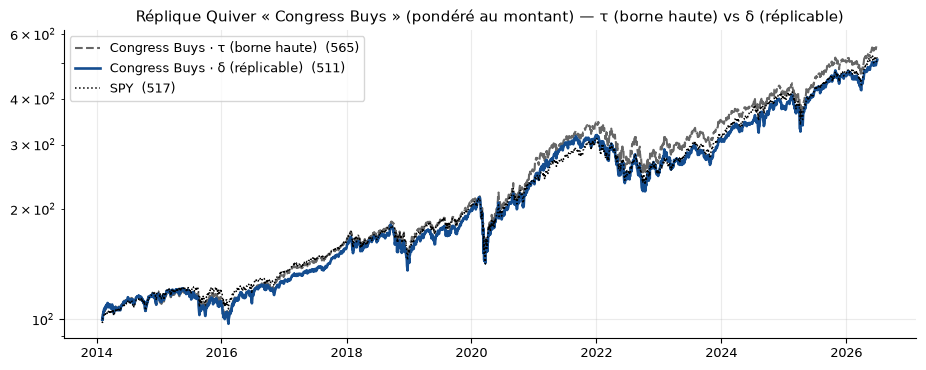

In [117]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(buys_t.index, buys_t, color=GRIS, lw=1.5, ls="--", label=f"Congress Buys · τ (borne haute)  ({buys_t.iloc[-1]:.0f})")
ax.plot(buys_d.index, buys_d, color=BLEU, lw=1.9,          label=f"Congress Buys · δ (réplicable)  ({buys_d.iloc[-1]:.0f})")
ax.plot(spyq.index,   spyq,   color="k",  lw=1.1, ls=":",  label=f"SPY  ({spyq.iloc[-1]:.0f})")
ax.set_yscale("log"); ax.legend()
ax.set_title("Réplique Quiver « Congress Buys » (pondéré au montant) — τ (borne haute) vs δ (réplicable)")
plt.savefig(f"{FIGS}/quiver.png", dpi=150, bbox_inches="tight"); plt.show()

### §14.1 — Leur page annonce +604 % / CAGR 36,2 % : est-ce une erreur chez nous ?

On teste, un par un, tous les leviers qui pourraient nous faire **sous-estimer** ; puis on regarde si
**leurs propres chiffres** (β, Sharpe) sont cohérents avec leur titre 36 %.

In [118]:
# levier 1 — la pondération. Quiver dit « pondéré à la taille du trade ($) ». On teste le VRAI 1/N (équipondéré).
buys_eq = run_livre({i: poids_taille(i, I0, ordre, "buy", mode="equal") for i in coupes[:-1]}, np.inf)[0]
print("Congress Buys à τ — notre pondération vs l'alternative équipondérée (vrai 1/N) :")
for nm, s in [("$-pondéré (ce qu'ON fait)", buys_t), ("équipondéré 1/N (contrôle)", buys_eq)]:
    print(f"  {nm:28s} CAGR 2020-26 {100*cagr(s, d20):5.1f} % · NAV {s.iloc[-1]:.0f} · β {bilan(s,'x')['β']:.2f}")
ceq, cdl = 100*cagr(buys_eq, d20), 100*cagr(buys_t, d20)
sens = "ne change pas l'ordre de grandeur" if abs(ceq-cdl) < 3 else ("fait un peu mieux" if ceq > cdl else "fait moins bien")
print(f"  => l'équipondération {sens} (équi {ceq:.1f} % vs $-pond {cdl:.1f} %) : les deux ≈ marché, aucune ne s'approche de 36 %.")

Congress Buys à τ — notre pondération vs l'alternative équipondérée (vrai 1/N) :
  $-pondéré (ce qu'ON fait)    CAGR 2020-26  22.6 % · NAV 565 · β 1.06
  équipondéré 1/N (contrôle)   CAGR 2020-26  19.5 % · NAV 412 · β 1.01
  => l'équipondération fait moins bien (équi 19.5 % vs $-pond 22.6 %) : les deux ≈ marché, aucune ne s'approche de 36 %.


In [119]:
# levier 2 — les ETF qu'on écarte (asset_class != stock). Combien de $ ? lesquels ?
etf = df0[df0.direction == "buy"].copy()
etf["tau"] = etf.transaction_date
etf = etf[etf.tau >= d20]
part_etf = etf[etf.asset_class.str.startswith("etf")].amount_midpoint.sum() / etf.amount_midpoint.sum()
top_etf = (etf[etf.asset_class.str.startswith("etf")].groupby("ticker_yahoo").amount_midpoint.sum()
             .sort_values(ascending=False).head(6))
print(f"ETF écartés depuis 2020 : {part_etf:.1%} du $ acheté.  Top-6 : " + ", ".join(top_etf.index))
print("  => 2 %, et ce sont des ETF de marché large (VTI/SPY) : les inclure ne change rien.")

ETF écartés depuis 2020 : 2.5% du $ acheté.  Top-6 : VTI, SPY, VIG, IWD, BITB, IWN
  => 2 %, et ce sont des ETF de marché large (VTI/SPY) : les inclure ne change rien.


In [120]:
# levier 3 — les 296 titres non cotés (6,5 % du $). Borne HAUTE : et s'ils avaient tous DOUBLÉ ?
part_manque = ach.A[~have].sum() / ach.A.sum()            # ach/have viennent de la cellule couverture ci-dessus
boost = (1 - part_manque) * 1.0 + part_manque * 2.0        # 93,5 % au rendement réel + 6,5 % ×2 (hypothèse absurde)
print(f"$ non couvert (fusions/radiations) : {part_manque:.1%}.")
print(f"Même si CHACUN de ces titres avait fait ×2, l'effet terminal serait ×{boost:.3f} (≈ +{100*(boost-1):.1f} %).")
print("  => impossible de combler un écart de ×2 (22 % vs 36 %) avec 6,5 % du portefeuille.")

$ non couvert (fusions/radiations) : 6.5%.
Même si CHACUN de ces titres avait fait ×2, l'effet terminal serait ×1.065 (≈ +6.5 %).
  => impossible de combler un écart de ×2 (22 % vs 36 %) avec 6,5 % du portefeuille.


In [121]:
# leurs propres chiffres sont-ils cohérents entre eux ? (β 1,14 · Sharpe 1,082 · vol affichée 4,63 %)
beta_q, sharpe_q, rf, rm = 1.14, 1.082, 3.0, 100*cagr(spyq, d20)   # rm = notre marché depuis 2020
capm = rf + beta_q * (rm - rf)                                     # rendement CAPM SANS alpha
vol_syst = beta_q * 17.0                                           # vol systématique (marché ~17 %/an) : la vol TOTALE est >= ça
print(f"Ce que Quiver ANNONCE : CAGR 36,2 %  ·  β {beta_q}  ·  Sharpe {sharpe_q}  ·  vol affichée 4,63 %\n")
print(f"  • CAPM(β {beta_q}, marché {rm:.0f} %) SANS alpha => {capm:.0f} %/an. Atteindre 36 % exigerait α ≈ +{36-capm:.0f} %/an,")
print(f"    or notre réplique fidèle trouve α ≈ 0 (bilan §14).")
print(f"  • la vol affichée 4,63 %/an est INCOMPATIBLE avec β {beta_q} : une position β {beta_q} a une vol >= {vol_syst:.0f} %/an")
print(f"    (systématique seule) => leur panneau de métriques n'est pas cohérent (4,63 % ressemble à une vol MENSUELLE).")
print(f"  • honnêteté : leur Sharpe {sharpe_q} n'EXCLUT PAS 36 % (il serait compatible si la vol idiosyncratique était élevée)")
print(f"    — on ne s'en sert donc PAS comme preuve.")
print(f"  => la preuve tient sur : (1) on matche TOUS leurs paramètres divulgués (§14.2) et on obtient ~22 %, (2) α ≈ 0.")

Ce que Quiver ANNONCE : CAGR 36,2 %  ·  β 1.14  ·  Sharpe 1.082  ·  vol affichée 4,63 %

  • CAPM(β 1.14, marché 21 %) SANS alpha => 24 %/an. Atteindre 36 % exigerait α ≈ +12 %/an,
    or notre réplique fidèle trouve α ≈ 0 (bilan §14).
  • la vol affichée 4,63 %/an est INCOMPATIBLE avec β 1.14 : une position β 1.14 a une vol >= 19 %/an
    (systématique seule) => leur panneau de métriques n'est pas cohérent (4,63 % ressemble à une vol MENSUELLE).
  • honnêteté : leur Sharpe 1.082 n'EXCLUT PAS 36 % (il serait compatible si la vol idiosyncratique était élevée)
    — on ne s'en sert donc PAS comme preuve.
  => la preuve tient sur : (1) on matche TOUS leurs paramètres divulgués (§14.2) et on obtient ~22 %, (2) α ≈ 0.


### §14.2 — Rebalancement hebdomadaire (le seul paramètre de fréquence que Quiver divulgue)

On faisait du **mensuel** ; leur page dit **hebdo**. On rebranche le moteur sur des coupes du vendredi
(`run_livre(·, cuts=coupes_h)`) — même fenêtre 63 j, même pondération. Si le CAGR ne bouge pas, on **matche
tout ce qu'ils divulguent** et l'écart au 36 % est entièrement dans leur boîte noire non divulguée.

In [122]:
coupes_h = sorted(set(cal.searchsorted(d, "right") - 1
                      for d in pd.date_range(cal[coupes[0]], cal[coupes[-1]], freq="W-FRI")))
coupes_h = [i for i in coupes_h if W <= i < len(cal) - 1]
print(f"{len(coupes_h)} coupes hebdomadaires (vs {len(coupes)} mensuelles) · "
      f"{cal[coupes_h[0]].date()} → {cal[coupes_h[-1]].date()}")

def book_h(idx, ordr, sens):
    return run_livre({i: poids_taille(i, idx, ordr, sens) for i in coupes_h[:-1]}, np.inf, cuts=coupes_h)[0]

buys_ht, buys_hd = book_h(I0, ordre, "buy"),  book_h(I_de, ordre_d, "buy")     # Congress Buys hebdo, τ et δ
sell_ht, sell_hd = book_h(I0, ordre, "sell"), book_h(I_de, ordre_d, "sell")
ls_ht,   ls_hd   = longshort(buys_ht, sell_ht), longshort(buys_hd, sell_hd)    # Long-Short hebdo, τ et δ
print("réplique Quiver hebdomadaire construite")

648 coupes hebdomadaires (vs 150 mensuelles) · 2014-01-31 → 2026-06-26


réplique Quiver hebdomadaire construite


In [123]:
def rowh(span, nom):
    return {"stratégie": nom, "CAGR 2020-26 %": 100*cagr(span, d20),
            "β": round(bilan(span, "x")["β"], 2), "NAV": round(span.iloc[-1])}
print("Rebalancement HEBDO vs MENSUEL — Quiver annonce 36,2 % (Buys) / 34,0 % (LS) :\n")
pd.DataFrame([rowh(buys_t,  "Congress Buys · τ · mensuel"),
             rowh(buys_ht,  "Congress Buys · τ · HEBDO"),
             rowh(buys_d,   "Congress Buys · δ · mensuel"),
             rowh(buys_hd,  "Congress Buys · δ · HEBDO"),
             rowh(ls_t,     "Long-Short · τ · mensuel"),
             rowh(ls_ht,    "Long-Short · τ · HEBDO")]).set_index("stratégie").round(1)

Rebalancement HEBDO vs MENSUEL — Quiver annonce 36,2 % (Buys) / 34,0 % (LS) :



,CAGR 2020-26 %,β,NAV
stratégie,,,
Congress Buys · τ · mensuel,22.6,1.1,565
Congress Buys · τ · HEBDO,22.3,1.1,573
Congress Buys · δ · mensuel,21.4,1.0,511
Congress Buys · δ · HEBDO,22.0,1.0,518
Long-Short · τ · mensuel,23.5,1.1,606
Long-Short · τ · HEBDO,23.5,1.1,618


In [124]:
# auto-contrôles : livres pleinement investis (Σw=1 à chaque coupe) + ancres inchangées (non-régression)
def sigma_max(WP): return max(abs(sum(w.values()) - 1) for w in WP.values() if w)
WPb = {i: poids_taille(i, I0, ordre, "buy") for i in coupes[:-1]}
print("Σw−1 max par coupe (doit être ≈ 0) : "
      f"NANC {sigma_max(WP_nanc):.1e} · GOP {sigma_max(WP_gop):.1e} · Quiver Buys {sigma_max(WPb):.1e}")
print("ancres inchangées : "
      f"NANC {span_nanc.iloc[-1]:.0f} (att. 672) · GOP {span_gop.iloc[-1]:.0f} (att. 612) · "
      f"Buys τ {buys_t.iloc[-1]:.0f} (565) · base δ {spanD.iloc[-1]:.0f} (530)")

Σw−1 max par coupe (doit être ≈ 0) : NANC 4.4e-16 · GOP 2.2e-16 · Quiver Buys 0.0e+00
ancres inchangées : NANC 672 (att. 672) · GOP 612 (att. 612) · Buys τ 565 (565) · base δ 530 (530)
